In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('/content/Banking.csv')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [11]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [12]:
# 1. Clean up that messy Client ID column name
df.rename(columns={'ï»¿Client ID': 'Client_ID'}, inplace=True)

# 2. Convert standard column spaces to underscores for easier dot-notation coding (Optional but helpful)
df.columns = df.columns.str.replace(' ', '_')

# 3. Convert 'Joined_Bank' from text to an actual datetime object
df['Joined_Bank'] = pd.to_datetime(df['Joined_Bank'])

# Let's see the updated column types
df.dtypes[['Client_ID', 'Joined_Bank']]

,0
Client_ID,object
Joined_Bank,datetime64[ns]


In [13]:
# 1. Fix the bins (using float('inf') for the maximum bound)
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Med', 'High']

# 2. Create the new Income Band column
# (Assuming your column is named 'Estimated_Income' after our previous cleanup)
df['Income_Band'] = pd.cut(df['Estimated_Income'], bins=bins, labels=labels)

# 3. Check how many customers fall into each band
print("Customer Count by Income Band:")
print(df['Income_Band'].value_counts())

Customer Count by Income Band:
Income_Band
Med     1517
Low     1027
High     456
Name: count, dtype: int64


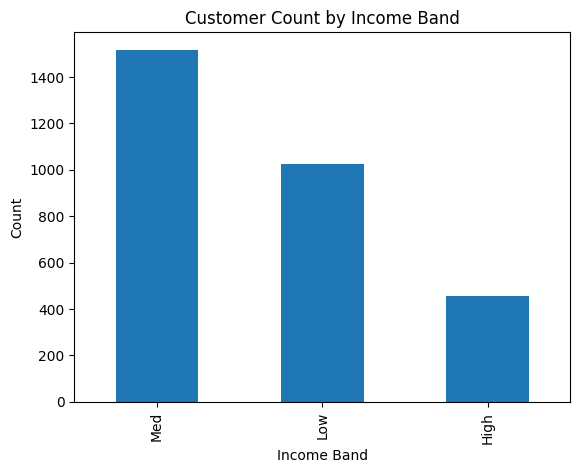

In [14]:
df['Income_Band'].value_counts().plot(kind='bar')
plt.title('Customer Count by Income Band')
plt.xlabel('Income Band')
plt.ylabel('Count')
plt.show()

In [15]:
# View summary stats for text/categorical columns
df.describe(include=['object', 'category'])

,Client_ID,Name,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,Income_Band
count,3000,3000,3000,3000,3000,3000,3000,3000
unique,2940,2913,49,5,195,3,4,3
top,IND48103,Jeremy Alexander,Ernest Rivera,European,Associate Professor,High,Jade,Med
freq,3,2,77,1309,28,1476,1331,1517


In [16]:
categorical_columns = df[['BRId', 'GenderId', 'IAId', 'Nationality', 'Occupation', 'Loyalty_Classification', 'Income_Band']]

for col in categorical_columns:
    print(f"=== Unique Value Distribution for: {col} ===")

    # Calculate counts and percentages
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    # Combine them side-by-side into a neat summary DataFrame
    summary_df = pd.concat([counts, percentages.round(2)], axis=1)
    summary_df.columns = ['Count', 'Percentage (%)']

    display(summary_df)
    print("\n" + "="*50 + "\n")

=== Unique Value Distribution for: BRId ===


,Count,Percentage (%)
BRId,,
3,1352,45.07
1,660,22.00
2,495,16.50
4,493,16.43




=== Unique Value Distribution for: GenderId ===


,Count,Percentage (%)
GenderId,,
2,1512,50.4
1,1488,49.6




=== Unique Value Distribution for: IAId ===


...

,Count,Percentage (%)
Occupation,,
Associate Professor,28,0.93
Structural Analysis Engineer,28,0.93
Recruiter,25,0.83
Account Coordinator,24,0.80
Human Resources Manager,24,0.80
...,...,...
Office Assistant IV,8,0.27
Automation Specialist I,7,0.23
Computer Systems Analyst I,6,0.20




=== Unique Value Distribution for: Loyalty_Classification ===


,Count,Percentage (%)
Loyalty_Classification,,
Jade,1331,44.37
Silver,767,25.57
Gold,585,19.50
Platinum,317,10.57




=== Unique Value Distribution for: Income_Band ===


,Count,Percentage (%)
Income_Band,,
Med,1517,50.57
Low,1027,34.23
High,456,15.20


**Univaraible Anaylsis**


/tmp/ipykernel_1947/4249718403.py:63: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


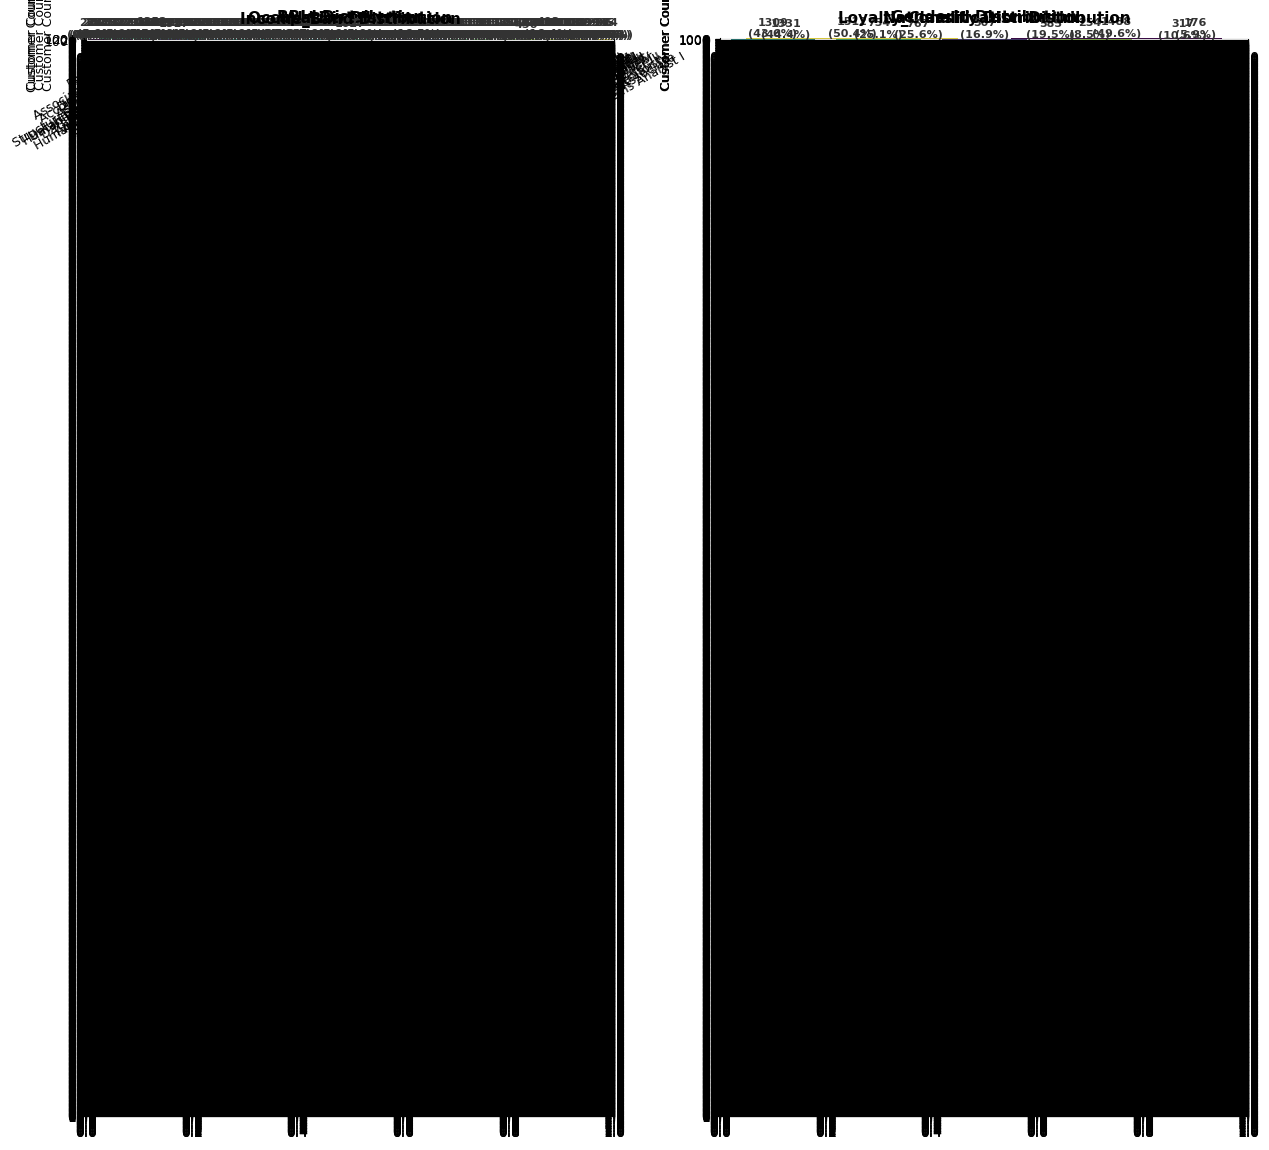

In [17]:
# 2. Configure a compact grid (2 columns wide, rows calculated without 'math')
n_cols = 2
n_rows = (len(categorical_columns) + 1) // n_cols  # Automatically resolves to exactly 4 rows

# 3. Create a professional, tightly-spaced layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 14))
axes = axes.flatten()  # Flatten the grid into a single linear checklist

# Total rows in the dataset to calculate percentages accurately
total_records = len(df)

# 4. Loop and plot each chart beautifully
for i, col in enumerate(categorical_columns):
    ax = axes[i]

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        palette='viridis',
        hue=col,
        legend=False,
        ax=ax
    )

    # 5. DYNAMIC LABELS: Loop through the bars and calculate Count + Percentage
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:  # Skip drawing text if the bar has no data
            percentage = (height / total_records) * 100

            # Formats label as: "Count (Pct%)" -> e.g., "1250 (41.7%)"
            label = f'{int(height)}\n({percentage:.1f}%)'

            # Place the text centered right above the top of each bar
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,  # X coordinate: center of the bar
                height + (total_records * 0.01),      # Y coordinate: slightly above the bar
                label,
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='semibold',
                color='#333333'
            )

    # Professional Styling Updates
    ax.set_title(f'{col} Distribution', fontsize=11, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=30, labelsize=9)  # Subtle 30-degree tilt for clean readability
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Customer Count', fontsize=9)

    # Pad the top of the Y-axis slightly so labels don't get cut off at the very top edge
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
    sns.despine(ax=ax)  # Removes heavy top and right borders for a modern look

# 6. Clean up: Instantly delete the 8th empty grid box
for j in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[j])

# Apply tight layout to eliminate overlapping text
plt.tight_layout()
plt.show()

Bivariate Anaylsis


/tmp/ipykernel_1947/3166754989.py:62: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


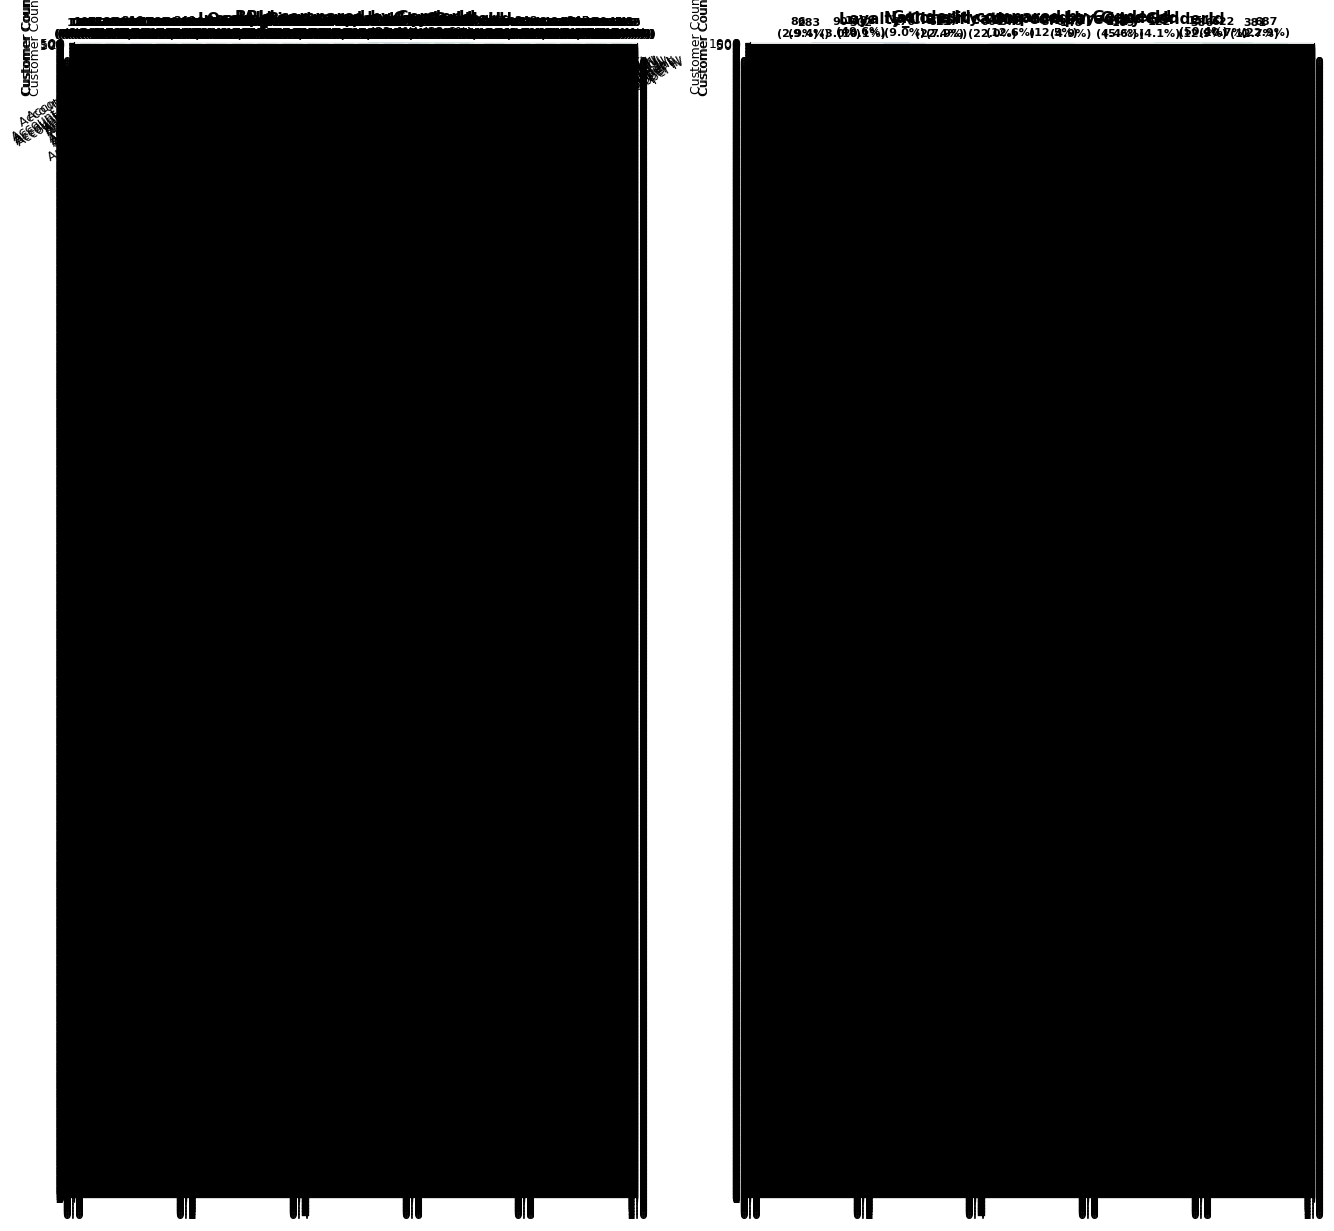

In [18]:

# 2. Configure a compact grid layout (2 columns wide)
n_cols = 2
n_rows = (len(categorical_columns) + 1) // n_cols  # Resolves to exactly 3 rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 15))
axes = axes.flatten()

# Get the total number of records for accurate percentage math
total_records = len(df)

# 3. Loop and plot each relationship
for i, col in enumerate(categorical_columns):
    ax = axes[i]

    # Create a cross-tabulation table
    crosstab_data = pd.crosstab(df[col], df['GenderId'])

    # Plot clustered/side-by-side columns
    crosstab_data.plot(
        kind='bar',
        stacked=False,
        ax=ax,
        color=sns.color_palette('viridis', n_colors=df['GenderId'].nunique()),
        width=0.8,
        edgecolor='white',
        linewidth=0.5
    )

    # 4. TOP LABELS: Calculate and display both Count and Percentage above each bar
    for container in ax.containers:
        labels = []
        for v in container.datavalues:
            if v > 0:
                pct = (v / total_records) * 100
                # Standard format: Count value on top line, percentage in parentheses below
                labels.append(f'{int(v)}\n({pct:.1f}%)')
            else:
                labels.append('')

        ax.bar_label(
            container,
            labels=labels,
            label_type='edge', # Places the stacked text perfectly on TOP of the bars
            fontsize=8,
            fontweight='semibold',
            padding=4          # Leaves a crisp gap between the bar top and the text
        )

    # Professional Styling Updates
    ax.set_title(f'{col} compared by GenderId', fontsize=11, fontweight='bold', pad=15)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Customer Count', fontsize=9)
    ax.legend(title='GenderId', frameon=False, fontsize=9)

    # Pad the top of the Y-axis ceiling by 20% so the double-line text labels never get clipped
    ax.set_ylim(0, ax.get_ylim()[1] * 1.20)
    sns.despine(ax=ax)

# Adjust layout to eliminate overlapping text
plt.tight_layout()
plt.show()

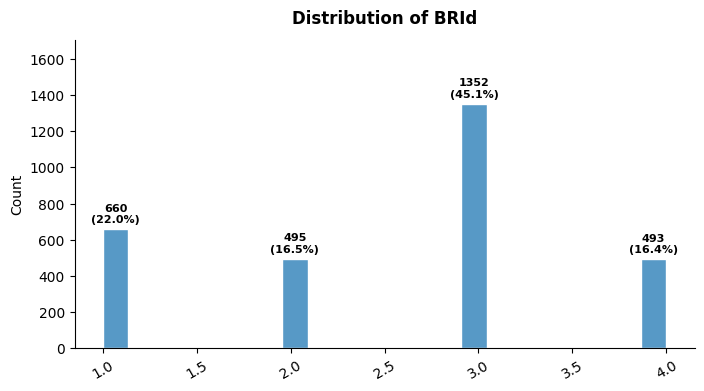

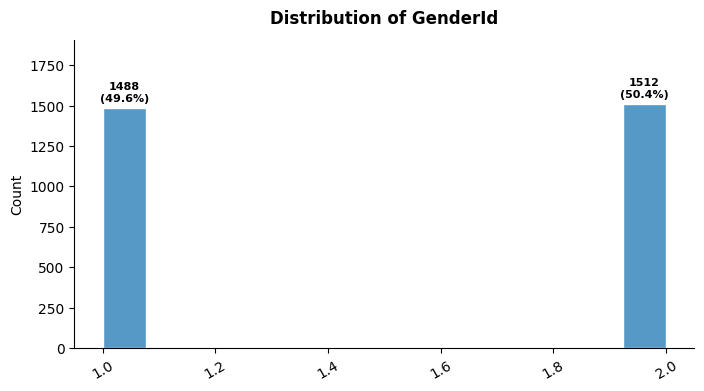

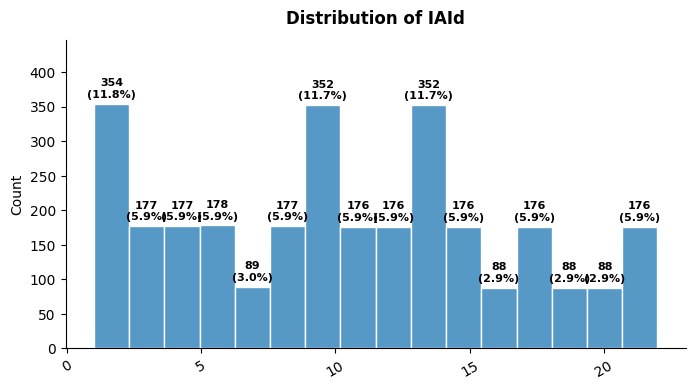

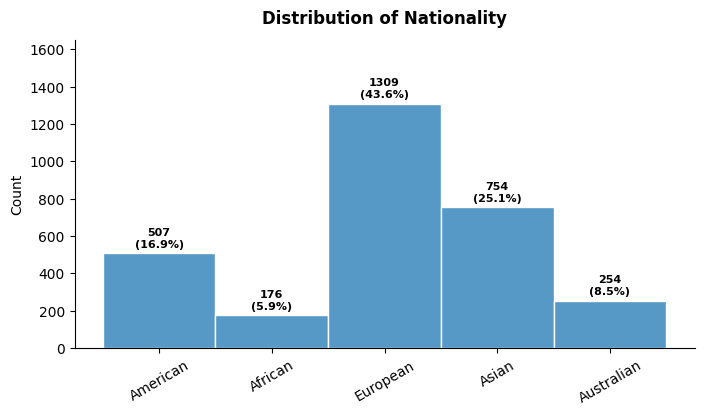

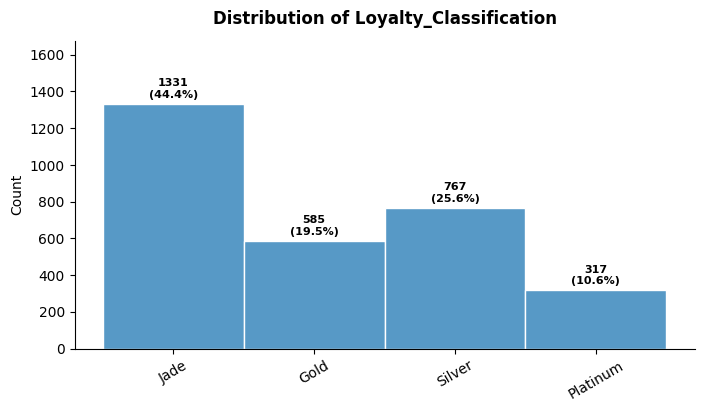

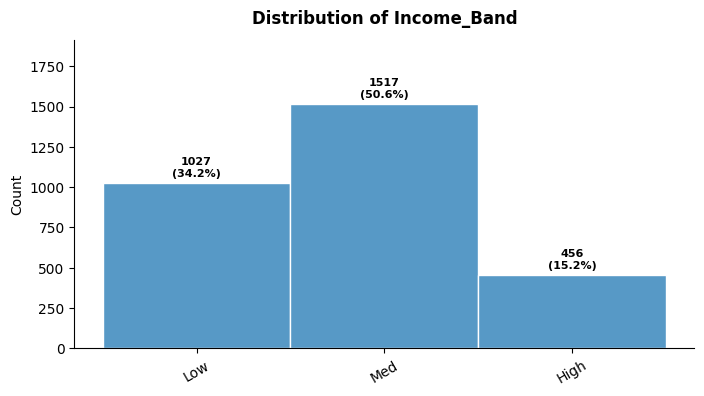

In [19]:
# Total records in the dataset for calculating percentages accurately
total_records = len(df)

for col in categorical_columns:
    # FIXED: Check the individual 'col' string to properly skip Occupation
    if col == 'Occupation':
        continue

    plt.figure(figsize=(8, 4))

    # Create the true histplot (bars touch side-by-side)
    ax = sns.histplot(data=df, x=col, edgecolor='white', linewidth=1)

    # DYNAMIC LABELS: Loop through the bars to calculate and display Count + Percentage
    for container in ax.containers:
        labels = []
        for v in container.datavalues:
            if v > 0:
                pct = (v / total_records) * 100
                labels.append(f'{int(v)}\n({pct:.1f}%)')
            else:
                labels.append('')

        # Place the text centered right above the top edge of each touching bar
        ax.bar_label(
            container,
            labels=labels,
            label_type='edge',
            fontsize=8,
            fontweight='semibold',
            padding=3
        )

    # Professional Styling Updates
    plt.title(f'Distribution of {col}', fontweight='bold', pad=12)
    plt.xticks(rotation=30)
    plt.xlabel('')
    plt.ylabel('Count')

    # Push the top of the chart up by 20% so the text labels don't get cut off
    ax.set_ylim(0, ax.get_ylim()[1] * 1.20)
    sns.despine()

    plt.show()

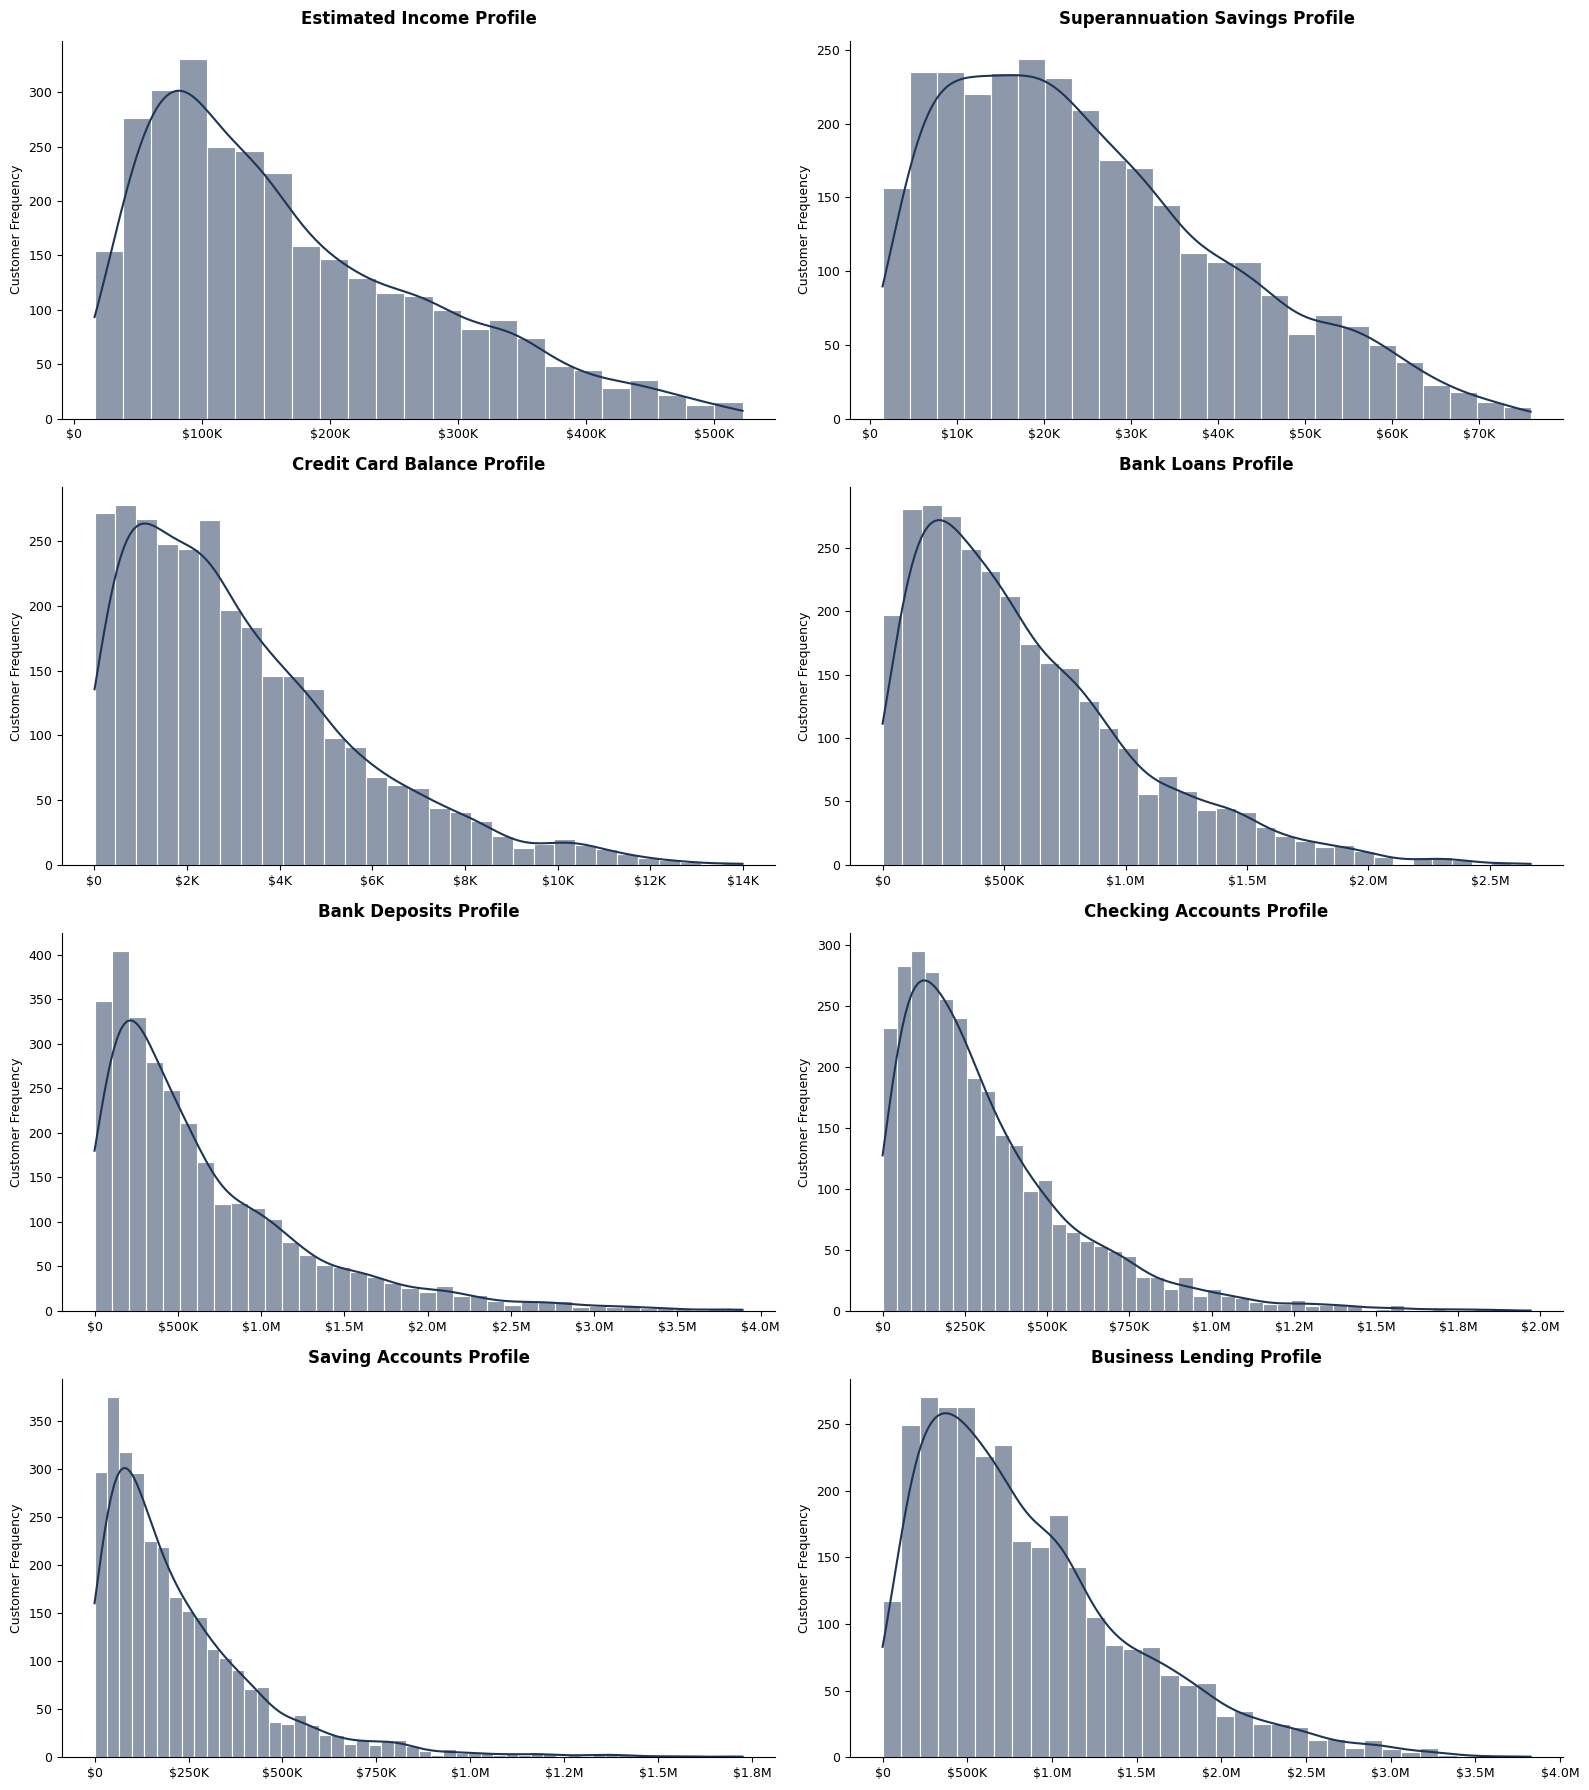

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Filter down to the continuous financial assets we want to analyze
financial_cols = [
    'Estimated_Income', 'Superannuation_Savings', 'Credit_Card_Balance',
    'Bank_Loans', 'Bank_Deposits', 'Checking_Accounts', 'Saving_Accounts',
    'Business_Lending'
]

# Set up a clean 4x2 dashboard grid layout
n_cols = 2
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

# Custom formatter function to clean up large banking figures
def currency_formatter(x, pos):
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    return f'${x:.0f}'

for i, col in enumerate(financial_cols):
    ax = axes[i]

    # Generate the true continuous histogram with a trend line
    sns.histplot(
        data=df,
        x=col,
        kde=True,                  # Smooth density trend curve
        color='#1d3557',           # Elegant deep navy color palette
        edgecolor='white',
        linewidth=0.8,
        ax=ax
    )

    # Format x-axis text dynamically based on the numbers
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))

    # Professional Styling Updates
    ax.set_title(f'{col.replace("_", " ")} Profile', fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(axis='both', labelsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Customer Frequency', fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

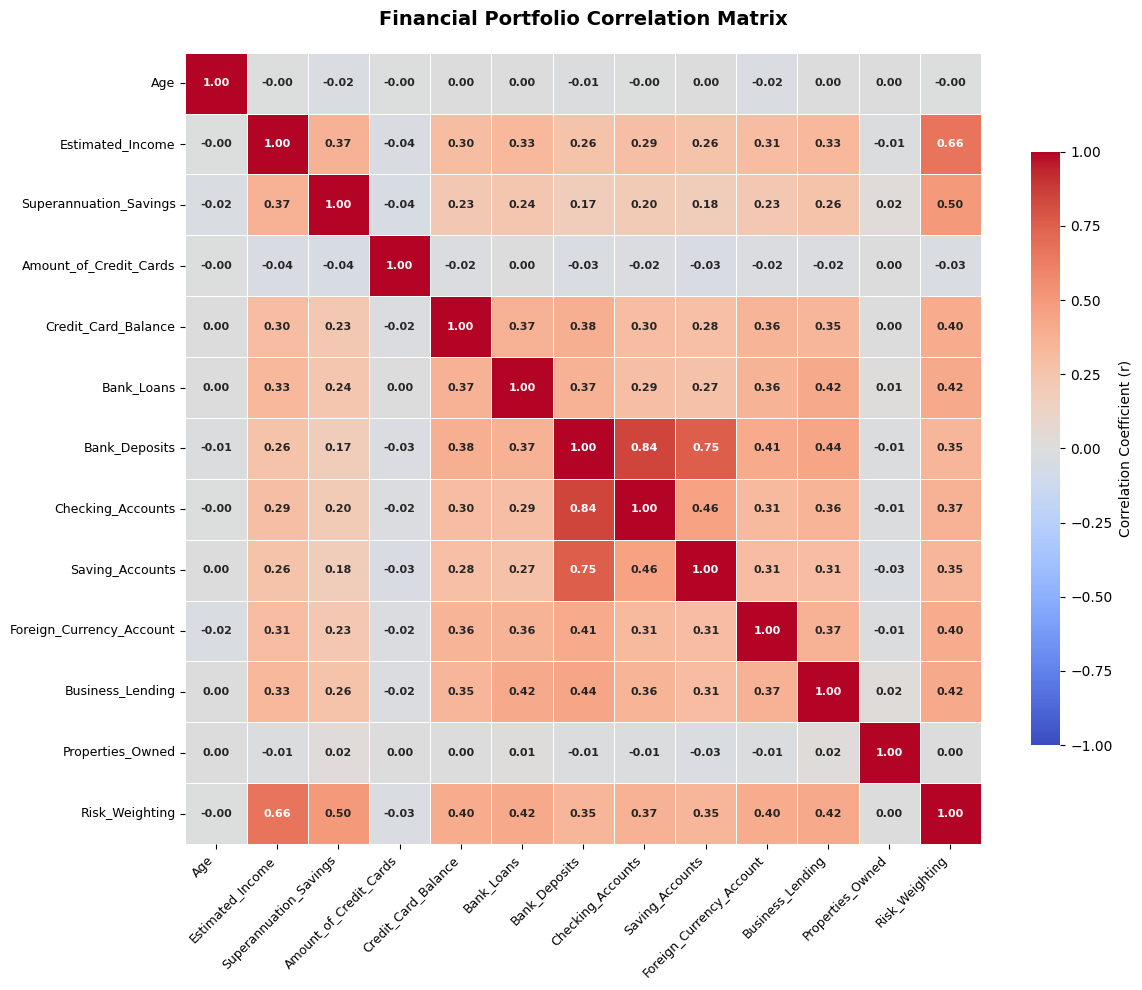

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the true numerical columns (excluding structural IDs)
num_cols = [
    'Age', 'Estimated_Income', 'Superannuation_Savings', 'Amount_of_Credit_Cards',
    'Credit_Card_Balance', 'Bank_Loans', 'Bank_Deposits', 'Checking_Accounts',
    'Saving_Accounts', 'Foreign_Currency_Account', 'Business_Lending',
    'Properties_Owned', 'Risk_Weighting'
]

# 2. Compute the correlation matrix
corr_matrix = df[num_cols].corr()


# 4. Initialize a clean, spacious plot footprint
plt.figure(figsize=(12, 10))

# 5. Draw the heatmap with professional formatting
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',       # Blue for negative correlation, Red for positive correlation
    vmax=1.0, vmin=-1.0,   # Force scale bounds to show true correlation strength
    center=0,
    annot=True,            # Write the correlation coefficients inside the squares
    fmt='.2f',             # Round numbers nicely to 2 decimal places
    linewidths=0.5,        # Thin crisp borders between grid cells
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient (r)"}, # Clean sidebar layout
    annot_kws={"size": 8, "weight": "semibold"}
)

# Professional Presentation Enhancements
plt.title('Financial Portfolio Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### 📊 Executive Financial Insights: Correlation Matrix Analysis

* **Core Wealth Engine:** `Estimated_Income` strongly drives a client's overall financial footprint, showing a dominant positive correlation with risk tolerance (`Risk_Weighting`: 0.66) and wealth accumulation (`Superannuation_Savings`: 0.50).
* **Liquid Capital Synergy:** A massive structural relationship exists within liquidity pools, where `Bank_Deposits` heavily dictate cash placement across transactional channels (`Checking_Accounts`: 0.84 and `Saving_Accounts`: 0.75).
* **Credit & Debt Interconnectedness:** Credit card usage and retail debt do not act in isolation; higher consumer leverage (`Credit_Card_Balance`) directly matches increased borrowing profiles across `Bank_Loans` (0.37) and `Bank_Deposits` (0.38).
* **Risk Sensitivity Profiles:** Higher bank exposure across lending tiers (`Business_Lending`, `Bank_Loans`) and credit channels presents a highly uniform upward pressure on individual risk parameters (`Risk_Weighting` clusters consistently between 0.35 and 0.42).
* **Demographic & Asset Neutrality:** From an economic standpoint, `Age`, `Properties_Owned`, and the `Amount_of_Credit_Cards` held are completely decoupled from core financial balances (correlations close to 0.00), proving product adoption is baseline-uniform across your entire demographic spectrum.

In [22]:
df.columns

Index(['Client_ID', 'Name', 'Age', 'Location_ID', 'Joined_Bank',
       'Banking_Contact', 'Nationality', 'Occupation', 'Fee_Structure',
       'Loyalty_Classification', 'Estimated_Income', 'Superannuation_Savings',
       'Amount_of_Credit_Cards', 'Credit_Card_Balance', 'Bank_Loans',
       'Bank_Deposits', 'Checking_Accounts', 'Saving_Accounts',
       'Foreign_Currency_Account', 'Business_Lending', 'Properties_Owned',
       'Risk_Weighting', 'BRId', 'GenderId', 'IAId', 'Income_Band'],
      dtype='object')

In [27]:
# Calculating Total Loan
df['Total_Loan'] = df['Bank_Loans'] + df['BusinessLending']
df['Total_Loan']
# Calculating Total Deposit
df['Total_Deposit'] = df[['Bank_Deposits', 'Checking_Accounts', 'Saving_Accounts', 'Foreign_Currency_Account']].sum(axis=1)

In [31]:
# Corrected syntax to calculate the sum of the entire column
total_loan_sum = df['Total_Loan'].sum()

print(total_loan_sum)

4374437891.68


In [24]:
df.describe()

,Age,Location_ID,Joined_Bank,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId,Total_Loan,Total_Deposit
count,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03
mean,51.039667,21563.323000,2010-08-15 00:03:21.600000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333,1.458146e+06,1.255445e+06
min,17.000000,12.000000,1995-01-03 00:00:00,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,5.552961e+04,9.540400e+02
25%,34.000000,10803.500000,2004-04-01 18:00:00,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000,7.669453e+05,4.576335e+05
50%,51.000000,21129.500000,2011-02-18 00:00:00,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000,1.222766e+06,9.436776e+05
75%,69.000000,32054.500000,2017-12-24 06:00:00,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000,1.954659e+06,1.736667e+06
max,85.000000,43369.000000,2021-12-31 00:00:00,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000,6.078478e+06,6.485442e+06
std,19.854760,12462.273017,NaN,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242,9.302074e+05,1.077426e+06


In [26]:
# Select only true numerical columns, excluding structural IDs
num_cols = [
    'Age', 'Estimated_Income', 'Superannuation_Savings', 'Amount_of_Credit_Cards',
    'Credit_Card_Balance', 'Bank_Loans', 'Bank_Deposits', 'Checking_Accounts',
    'Saving_Accounts', 'Foreign_Currency_Account', 'Business_Lending',
    'Properties_Owned', 'Risk_Weighting'
]

# Display count, mean, min, max, and percentiles
df[num_cols].describe().T.round()

,count,mean,std,min,25%,50%,75%,max
Age,3000.0,51.0,20.0,17.0,34.0,51.0,69.0,85.0
Estimated_Income,3000.0,171305.0,111936.0,15919.0,82907.0,142313.0,242290.0,522330.0
Superannuation_Savings,3000.0,25532.0,16260.0,1482.0,12514.0,22357.0,35465.0,75964.0
Amount_of_Credit_Cards,3000.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0
Credit_Card_Balance,3000.0,3176.0,2497.0,1.0,1237.0,2561.0,4523.0,13992.0
Bank_Loans,3000.0,591386.0,457557.0,0.0,239628.0,479793.0,825813.0,2667557.0
Bank_Deposits,3000.0,671560.0,645717.0,0.0,204400.0,463316.0,942755.0,3890598.0
Checking_Accounts,3000.0,321093.0,282080.0,0.0,119948.0,242816.0,434875.0,1969923.0
Saving_Accounts,3000.0,232908.0,230008.0,0.0,74794.0,164087.0,315575.0,1724118.0
Foreign_Currency_Account,3000.0,29884.0,23110.0,45.0,11917.0,24341.0,41966.0,124705.0
